In [ ]:
import numpy as np
import tensorflow as tf

# 1. Build graph using TF operations

$$H(x) = Wx + b$$

In [7]:
x_data = [1,2,3,4,5]
y_data = [2.1,3.1,4.1,5.1,6.1]

W = tf.Variable(2.9)
b = tf.Variable(0.5)

hypothesis = W * x_data + b

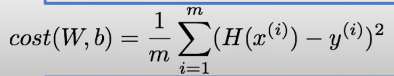

In [8]:
cost = tf.reduce_mean(tf.square(hypothesis - y_data))

GradientDescent

In [9]:
learning_rate = 0.01 

with tf.GradientTape() as tape:     # with 구문 안에 있는 변수 (W,b)의 정보를 tape에 저장한다. 
    hypothesis = W *x_data + b
    cost = tf.reduce_mean(tf.square(hypothesis - y_data))

W_grad, b_grad = tape.gradient(cost, [W, b])    # cost에 대해 W,b의 기울기를 구한다. (미분)

W.assign_sub(learning_rate * W_grad)            # 기울기에 학습률을 곱해서 W에서 뺀다.
b.assign_sub(learning_rate * b_grad)

<tf.Variable 'UnreadVariable' shape=() dtype=float32, numpy=0.398>

# 2. Parameter(W,b) Update

In [12]:
for i in range(1500):
    with tf.GradientTape() as tape:     # with 구문 안에 있는 변수 (W,b)의 정보를 tape에 저장한다. 
        hypothesis = W *x_data + b
        cost = tf.reduce_mean(tf.square(hypothesis - y_data))

    W_grad, b_grad = tape.gradient(cost, [W, b])    # cost에 대해 W,b의 기울기를 구한다. (미분)

    W.assign_sub(learning_rate * W_grad)            # 기울기에 학습률을 곱해서 W에서 뺀다.
    b.assign_sub(learning_rate * b_grad)
    if i % 100 == 0:
        print(f'{i}, {W.numpy()}, {b.numpy()}, {cost.numpy():.6f}')

0, 1.0069369077682495, 1.074955701828003, 0.000115
100, 1.00494384765625, 1.0821508169174194, 0.000058
200, 1.003523588180542, 1.0872783660888672, 0.000030
300, 1.0025113821029663, 1.0909333229064941, 0.000015
400, 1.001789927482605, 1.0935379266738892, 0.000008
500, 1.001275658607483, 1.0953946113586426, 0.000004
600, 1.0009092092514038, 1.0967175960540771, 0.000002
700, 1.0006481409072876, 1.0976600646972656, 0.000001
800, 1.0004620552062988, 1.0983320474624634, 0.000001
900, 1.0003294944763184, 1.0988106727600098, 0.000000
1000, 1.000234842300415, 1.099151849746704, 0.000000
1100, 1.0001674890518188, 1.0993949174880981, 0.000000
1200, 1.0001195669174194, 1.099568486213684, 0.000000
1300, 1.0000853538513184, 1.0996917486190796, 0.000000
1400, 1.000060796737671, 1.0997799634933472, 0.000000


W는 1, b는 0으로 수렴해갔다. 

# Predict

업데이트 된 W와 b를 이용해서 새로운 데이터 6을 대입해보니 6이라는 예측값을 얻었다.

In [ ]:
(W * 6 + b).numpy()

6.0029597

# 모델을 사용하는 방법

## 1. 훈련 데이터와 모델 객체 준비


In [13]:
import numpy as np
import tensorflow as tf

x_train = [1, 2, 3, 4, 5]
y_train = [1, 2, 3, 4, 5]

tf.model = tf.keras.Sequential()     # 모델을 객체 생성

## 2. 입력층과 출력층 생성

In [14]:
# units는 output shape, input_dim은 input shape이다.
tf.model.add(tf.keras.layers.Dense(units=1, input_dim=1))
tf.model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


## 3. 최적화 함수와 손실함수를 정의

In [15]:
sgd = tf.keras.optimizers.SGD(lr=0.1)  # SGD == standard gradient descendent, lr == learning rate
tf.model.compile(loss='mse', optimizer=sgd)  # mse == mean_squared_error, 1/m * sig (y'-y)^2

tf.model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/gradient_descent.py:102: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


## 4. 모델 학습

In [ ]:
tf.model.fit(x_train, y_train, epochs=200)

## 5. Predict

학습된 W와 b를 가지고 새로운 데이터를 예측해본다.

In [18]:
y_predict = tf.model.predict(np.array([6]))
print(y_predict)

[[-1.2139571e+28]]


# 전체 코드

In [6]:
# import numpy as np
# import tensorflow as tf

# x_train = [1, 2, 3, 4]
# y_train = [0, -1, -2, -3]

# tf.model = tf.keras.Sequential()     # 모델을 생성
# # units == output shape, input_dim == input shape
# tf.model.add(tf.keras.layers.Dense(units=1, input_dim=1))

# sgd = tf.keras.optimizers.SGD(lr=0.1)  # SGD == standard gradient descendent, lr == learning rate
# tf.model.compile(loss='mse', optimizer=sgd)  # mse == mean_squared_error, 1/m * sig (y'-y)^2

# # prints summary of the model to the terminal
# tf.model.summary()

# # fit() executes training
# tf.model.fit(x_train, y_train, epochs=200)

# # predict() returns predicted value
# y_predict = tf.model.predict(np.array([5, 4]))
# print(y_predict)